# Puzzle

https://thefiddler.substack.com/p/will-you-be-right-on-time

### This Week’s Fiddler

From Steve Curry comes a puzzle that’s right on schedule:

A standard analog clock includes an hour hand, a minute hand, and 60 minute markers, 12 of which are also hour markers.

At a certain time, both the hour hand and minute hand are both pointing directly at minute markers (either of which could also be an hour marker). The hour hand is 13 markers ahead (i.e., clockwise) of the minute hand.

At what time does this occur? (Don’t worry about a.m. vs. p.m. for this puzzle.)

### This Week’s Extra Credit

At various times of day, the minute and hour hands form a right angle. But is there a time of day when the hour hand, minute hand, and second hand—each of which rotates in a continuous manner—together form two right angles, with any of the hands in the middle? If you can find such a time or times, what are they?

If you cannot find any such times, suppose the measures of the two nearly right angles formed by the three hands measure A and B degrees. What time or times of day minimize the square error function f(A, B) = (A − 90)^2 + (B − 90)^2?

Either way, your answer should be precise to at least a thousandth of a second. (Again, don’t worry about a.m. vs. p.m. for this puzzle.)

# Fiddler Solution

The hour hand moves 5 minute markers in 60 minutes, i.e. it moves one minute marker in 12 minutes.

Since the hour hand is pointing directly at a minute marker, the minute hand must be at a multiple of 12 minutes, i.e. 0, 12, 24, 36, 48.

When the minute hand is at 0, the hour hand must be at a multiple of 5 (5k) minutes. 13 minutes ahead of 0 would be 13, which is not a multiple of 5.

When the minute hand is at 12, the hour hand must be at 5k+1 minutes. 13 minutes ahead of 12 would be 25, which is not 5k+1.

When the minute hand is at 24, the hour hand must be at 5k+2 minutes. 13 minutes ahead of 24 would be 37, which is 5k+2 !!

When the minute hand is at 36, the hour hand must be at 5k+3 minutes. 13 minutes ahead of 36 would be 49, which is not 5k+3.

When the minute hand is at 48, the hour hand must be at 5k+4 minutes. 13 minutes ahead of 48 would be 1, which is not 5k+4.

So, the minute hand is at 34, the hour hand is at 37.

**The time is 7:24** 

# Extra Credit Solution

I think it is easy to guess some almost solutions like 6:00:15 or 3:30:45, but it is hard to be sure of which is the best, and what is the exact best value. So, let's try coding up something.

In [41]:
# Preliminary functions for clock angle calculations
def tsec_from_hms(h, m, s):
    return h * 3600 + m * 60 + s

def hms_from_tsec(tsec):
    h = tsec // 3600
    tsec %= 3600
    m = tsec // 60
    s = tsec % 60
    return h, m, s

def hms_angles_from_tsec(tsec):
    sa = (tsec % 60) * 360 / 60
    ma = (tsec % 3600) * 360 / 3600
    ha = (tsec % 43200) * 360 / 43200
    return ha, ma, sa

In [42]:
def error_F(tsec, debug=False):
    #import numpy as np
    #tsec = float(np.atleast_1d(tsec)[0])
    h, m, s = hms_from_tsec(tsec)
    hour_angle, minute_angle, second_angle = hms_angles_from_tsec(tsec)
    if debug:
        print(f"Time: {tsec}: {h}:{m}:{s} -> Angles: H={hour_angle}, M={minute_angle}, S={second_angle}")
    x,y,z = sorted([hour_angle, minute_angle, second_angle], reverse=True)
    p = x - y
    q = y - z
    r = z - x + 360
    a, b, c = sorted([p, q, r])
    if debug:
        print(f"Angles sorted: {x}, {y}, {z} -> Differences: p={p}, q={q}, r={r} -> Sorted differences: a={a}, b={b}, c={c}")
    error = (a - 90) ** 2 + (b - 90) ** 2 
    return error

error_F(5567.7643, debug=True)

Time: 5567.7643: 1.0:32.0:47.76429999999982 -> Angles: H=46.39803583333333, M=196.77642999999998, S=286.5857999999989
Angles sorted: 286.5857999999989, 196.77642999999998, 46.39803583333333 -> Differences: p=89.80936999999895, q=150.37839416666665, r=119.8122358333344 -> Sorted differences: a=89.80936999999895, b=119.8122358333344, c=150.37839416666665


888.8057451792479

In [43]:
initial_guesses = []
for h in range(12):
    for rel_m in [15, 30, 45]:
        for rel_s in [15, 30, 45]:
            if rel_m != rel_s:
                m = (h * 5 + rel_m) % 60
                s = (h * 5 + rel_s) % 60
                # Extra adjustment to move m by the amount the hour hand has moved in m minutes.
                m = (m + (m // 12)) % 60
                initial_guesses.append(tsec_from_hms(h, m, s))

#print("Initial guesses (in seconds): len =", len(initial_guesses))
#for guess in initial_guesses:   print(guess)

In [44]:
from scipy.optimize import minimize, minimize_scalar
results = []
for guess in initial_guesses:
    #res = minimize_scalar(error_F, bracket=(guess - 1, guess + 1), bounds=(0, 12 * 3600), method='bounded')
    res = minimize(error_F, guess, bounds=[(0, 12 * 3600)])
    results.append(res.x[0])

results.sort(key=lambda r: error_F(r))

for res in results:
    print ("Exact time:", res, " Time (h, m, s):", hms_from_tsec(float(res)), "Error:", error_F(float(res)))

Exact time: 1967.764295705675  Time (h, m, s): (0.0, 32.0, 47.76429570567507) Error: 0.07159517788309042
Exact time: 12767.764295705185  Time (h, m, s): (3.0, 32.0, 47.76429570518485) Error: 0.17953130587175503
Exact time: 17679.58036151926  Time (h, m, s): (4.0, 54.0, 39.580361519259895) Error: 0.24965470898383116
Exact time: 6879.580362543247  Time (h, m, s): (1.0, 54.0, 39.58036254324725) Error: 0.6210788005170914
Exact time: 33391.52308104034  Time (h, m, s): (9.0, 16.0, 31.523081040337274) Error: 0.7672059991831105
Exact time: 991.52308104953  Time (h, m, s): (0.0, 16.0, 31.523081049529992) Error: 0.7916072479232734
Exact time: 25520.498618793757  Time (h, m, s): (7.0, 5.0, 20.498618793757487) Error: 0.9900540810280277
Exact time: 36320.498618817524  Time (h, m, s): (10.0, 5.0, 20.498618817524402) Error: 1.2726745994978086
Exact time: 4896.53420023633  Time (h, m, s): (1.0, 21.0, 36.534200236330435) Error: 1.5257737662496182
Exact time: 37296.53420001439  Time (h, m, s): (10.0, 21

In [45]:
# This confirms the above results, and shows that 6 decimal digits are stable, but the lower ones may be noisy. 
# Not very insightful otherwise.

#exhaustive_results = []
#for sec in range(12 * 3600):
#    res = minimize(error_F, sec, bounds=[(0, 12 * 3600)])
#    if (res.x[0] not in exhaustive_results):
#        exhaustive_results.append(res.x[0])

#exhaustive_results.sort(key=lambda r: error_F(r))

#for res in exhaustive_results[0:20]:
#    print ("Exact time:", res, " Time (h, m, s):", hms_from_sec(float(res)), "Error:", error_F(float(res)))

In [46]:
x = 1967.7642957 - 12767.7642957
print("Difference between the two times in seconds:", x)

print(error_F(1967.7642957, debug=True))
print(error_F(12767.7642957, debug=True))

Difference between the two times in seconds: -10800.0
Time: 1967.7642957: 0.0:32.0:47.76429570000005 -> Angles: H=16.3980357975, M=196.77642957, S=286.58577420000023
Angles sorted: 286.58577420000023, 196.77642957, 16.3980357975 -> Differences: p=89.80934463000023, q=180.3783937725, r=89.81226159749974 -> Sorted differences: a=89.80934463000023, b=89.81226159749974, c=180.3783937725
0.07159517788309991
Time: 12767.7642957: 3.0:32.0:47.76429570000073 -> Angles: H=106.39803579750001, M=196.77642957000006, S=286.5857742000044
Angles sorted: 286.5857742000044, 196.77642957000006, 106.39803579750001 -> Differences: p=89.80934463000432, q=90.37839377250005, r=179.81226159749565 -> Sorted differences: a=89.80934463000432, b=90.37839377250005, c=179.81226159749565
0.1795313171750076


I was having a hard time seeing why 3:32:47... and 0:32:47.... have different errors.

Actually, looks like the difference angles are slightly different, because things aren't quite ninety degrees. So, they really do have different errors.

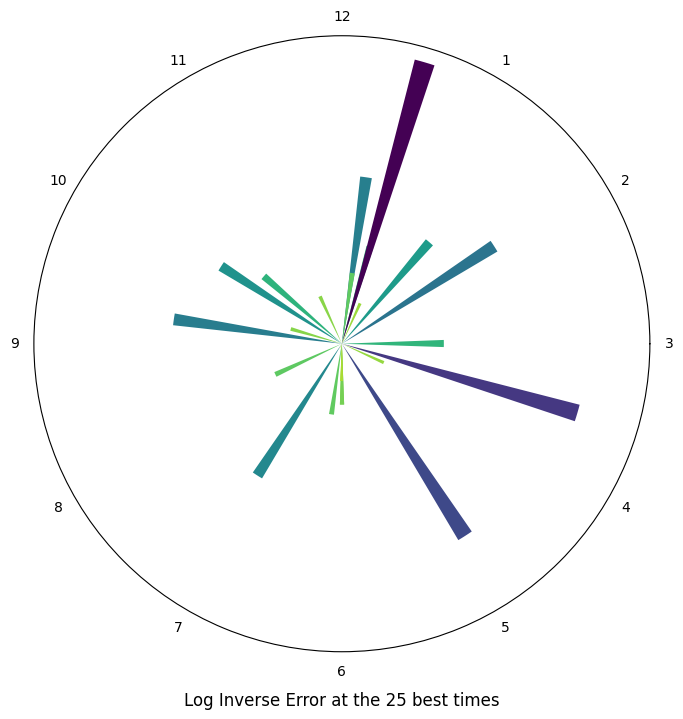

In [47]:
# Create a radial plot of the error function around clock.

from matplotlib import pyplot as plt
from math import pi, log

results_by_time = sorted(results)
radii = []
thetas = []
threshold = 20
for tsec in results_by_time:
    err = error_F(tsec)
    if err < threshold:
        hour_angle, _, _ = hms_angles_from_tsec(tsec)
        theta = ((90 - hour_angle) % 360) * pi / 180
        radii.append((log(threshold/err)))
        thetas.append(theta)
max_radius = max(radii) if radii else 1
colors = plt.cm.viridis([1-(r/max_radius) for r in radii])

fig, axs = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=(8, 8))
axs.bar(thetas, radii, color=colors, width=0.07, bottom=0)
axs.set_xticks([k*pi/6 for k in range(12)])
axs.set_xticklabels([f"{((2-k)%12)+1}" for k in range(12)])
axs.grid(False)
axs.set_yticks([])
axs.set_title(f"Log Inverse Error at the {len(radii)} best times", y=-0.1)
plt.show()

# Conclusions

Fiddler Answer is 7:24

Extra Credit Answer is 12:32:47.7642957 (i.e. 1967.7642957 seconds )

It's possible to plot the error function on the clock and create a pretty diagram. :)

# Post-Mortem

Official solution is here: https://thefiddler.substack.com/p/can-you-hop-around-the-chessboard

I actually got this wrong, and I think it's worth sorting out what was wrong.

In [48]:
error_1 = error_F(1967.7642957)
error_2 = error_F(13744.0786)
error_3 = error_F(29455.9214)

print("Error at 1967.7642957 seconds:", error_1)
print("Error at 13744.0786 seconds:", error_2)
print("Error at 29455.9214 seconds:", error_3)

Error at 1967.7642957 seconds: 0.07159517788309991
Error at 13744.0786 seconds: 0.007955091736113088
Error at 29455.9214 seconds: 0.007955091736111315


Okay, so my error function is correct, but my process for finding minima clearly messed up.

I tried to be clever with this use of scipy.minimize, but would clearly have been better to go with a simpler brute force approach.

So, what is this minimize function doing?

In [49]:
minimize(error_F, 13744.0786, bounds=[(0, 12 * 3600)])

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 18.10853984474774
        x: [ 1.370e+04]
      nit: 4
      jac: [-3.552e-07]
     nfev: 20
     njev: 10
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

In [50]:
res = minimize(error_F, 13744.0786, bounds=[(13744, 13745)])
print(res, "\n", res.x[0], res.fun)

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 8004.444444444444
        x: [ 1.374e+04]
      nit: 1
      jac: [ 1.067e+03]
     nfev: 4
     njev: 2
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64> 
 13744.0 8004.444444444444


In [51]:
minimize(error_F, 13744.0786, bounds=[(0, 12 * 3600)], method='Nelder-Mead')

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1010.6319693977206
             x: [ 1.340e+04]
           nit: 24
          nfev: 52
 final_simplex: (array([[ 1.340e+04],
                       [ 1.340e+04]]), array([ 1.011e+03,  1.011e+03]))

In [52]:
minimize(error_F, 13744.0786, bounds=[(13744, 13745)], method='Nelder-Mead')

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 8004.444444444444
             x: [ 1.374e+04]
           nit: 2
          nfev: 4
 final_simplex: (array([[ 1.374e+04],
                       [ 1.374e+04]]), array([ 8.004e+03,  8.004e+03]))

In [53]:
minimize_scalar(error_F,  bounds=(13744, 13745))

 message: Solution found.
 success: True
  status: 0
     fun: 0.00795501976478219
       x: 13744.078568096442
     nit: 6
    nfev: 6

In [54]:
minimize_scalar(error_F,  bounds=(13740, 13750))

 message: Solution found.
 success: True
  status: 0
     fun: 0.00795501976478219
       x: 13744.078568096442
     nit: 6
    nfev: 6

So, in summary, minimize_scalar works as one would expect, and is the function I should have used instead of minimize.

And I have no idea what the minimize function is doing. It can't find the minima even when you point it out with tight bounds to match.

And the initial_guesses part in my earlier code is correct, but not comprehensive, so it can guide one to one of the minima, but not the other one. So, all that put together...

In [55]:
results = []
for guess in range(0,12*3600, 10):
    res = minimize_scalar(error_F, bounds=(guess - 6, guess + 6))
    results.append(res.x)

results.sort(key=lambda r: error_F(r))

for res in results[:20]:
    print ("Exact time:", res, " Time (h, m, s):", hms_from_tsec(float(res)), "Error:", error_F(float(res)))

Exact time: 13744.078568096442  Time (h, m, s): (3.0, 49.0, 4.078568096441813) Error: 0.00795501976478219
Exact time: 13744.078568096442  Time (h, m, s): (3.0, 49.0, 4.078568096441813) Error: 0.00795501976478219
Exact time: 29455.921431903556  Time (h, m, s): (8.0, 10.0, 55.92143190355637) Error: 0.007955019764785295
Exact time: 29455.921431903556  Time (h, m, s): (8.0, 10.0, 55.92143190355637) Error: 0.007955019764785295
Exact time: 18655.931868723637  Time (h, m, s): (5.0, 10.0, 55.93186872363731) Error: 0.0161552499576174
Exact time: 18655.931868723637  Time (h, m, s): (5.0, 10.0, 55.93186872363731) Error: 0.0161552499576174
Exact time: 24544.068131276363  Time (h, m, s): (6.0, 49.0, 4.068131276362692) Error: 0.016155249957639298
Exact time: 24544.068131276363  Time (h, m, s): (6.0, 49.0, 4.068131276362692) Error: 0.016155249957639298
Exact time: 38288.178664119034  Time (h, m, s): (10.0, 38.0, 8.178664119033783) Error: 0.0626593074212534
Exact time: 16688.178664119037  Time (h, m, 

Okay, this revised code which checks every 10 second interval using the correct minimize_scalar function can find both minima. And it runs in 0.5 seconds. 

KISS.

Phew.

# What's going on with SciPy Minimize?

Sorting out this library usage some more.


In [56]:
from scipy.optimize import minimize
def simplified_error_F(tsec):
    second_angle = (tsec % 60) * 360 / 60
    minute_angle = (tsec % 3600) * 360 / 3600
    hour_angle = (tsec % 43200) * 360 / 43200
    x,y,z = sorted([hour_angle, minute_angle, second_angle], reverse=True)
    p = x - y
    q = y - z
    r = z - x + 360
    a, b, c = sorted([p, q, r])
    error = (a - 90) ** 2 + (b - 90) ** 2 
    return error

In [57]:
res = minimize(simplified_error_F, x0=13744, bounds=[(13744, 13745)])
print (res, "\n", res.x[0], res.fun)

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.007955019764783423
        x: [ 1.374e+04]
      nit: 1
      jac: [ 7.977e-07]
     nfev: 6
     njev: 3
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64> 
 13744.078568093431 0.007955019764783423


Wait, minimize is working once I simplified things. Maybe the debug flag messes things up?

In [58]:
res = minimize(error_F, x0=13744, bounds=[(13744, 13745)])
print (res, "\n", res.x[0], res.fun)

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 8004.444444444444
        x: [ 1.374e+04]
      nit: 0
      jac: [ 1.067e+03]
     nfev: 2
     njev: 1
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64> 
 13744.0 8004.444444444444


In [59]:
def wrapped_error_F(tsec):
    return error_F(tsec, debug=False)

res = minimize(wrapped_error_F, x0=13744, bounds=[(13744, 13745)])
print (res, "\n", res.x[0], res.fun)

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 8004.444444444444
        x: [ 1.374e+04]
      nit: 0
      jac: [ 1.067e+03]
     nfev: 2
     njev: 1
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64> 
 13744.0 8004.444444444444


Hmm, I don't see any difference between wrapped_error_F and simplified_error_F, but one works and one doesn't??

In [60]:
from math import isclose
for f in [error_F,  wrapped_error_F, simplified_error_F]:
    res = minimize(f, x0=13744, bounds=[(13744, 13745)])
    print (f.__name__, "minimize\n  ", res.x[0], res.fun)
    res = minimize_scalar(f, bounds=(13744, 13745))
    print (f.__name__, "minimize_scalar\n  ", res.x, res.fun)

error_F minimize
   13744.0 8004.444444444444
error_F minimize_scalar
   13744.078568096442 0.00795501976478219
wrapped_error_F minimize
   13744.0 8004.444444444444
wrapped_error_F minimize_scalar
   13744.078568096442 0.00795501976478219
simplified_error_F minimize
   13744.078568093431 0.007955019764783423
simplified_error_F minimize_scalar
   13744.078568096442 0.00795501976478219


To summarize, simplified_error_F works correctly with both minimize and minimize_scalar, but error_F and wrapped_error_F only work with minimize_scalar.

Finally some chatting with copilot chat (gpt-5) reveals the explanation:

    Short answer: scipy.optimize.minimize passes an array-like x (an ndarray) even for 1-D problems, while minimize_scalar passes a plain Python float. Your error_F / wrapped_error_F assume sec is a scalar and use integer-division / modulo and hms_from_tsec, which produce NumPy arrays when sec is an ndarray. Later you do comparisons/sorting on those (or other operations that expect scalars) and that triggers ambiguous-array behavior. simplified_error_F happens to avoid the problematic path, so it appears to work.

    Fix (make the objective robust to either input type). At the top of error_F and wrapped_error_F coerce sec to a scalar:

    Add import numpy as np
    Convert the input: sec = np.asarray(sec).ravel()[0] (or sec = np.asarray(sec).item() if you expect a size-1 array)
    Example:

    from numpy import asarray
    def error_F(sec, debug=False):
    sec = asarray(sec).ravel()[0]
    h, m, s = hms_from_tsec(sec)
    ... # rest unchanged

    Or:

    def error_F(sec, debug=False):
    import numpy as np
    sec = float(np.atleast_1d(sec)[0])
    ...

    Either of those makes the function accept both minimize (which gives an ndarray) and minimize_scalar (which gives a float).

And indeed, making that change fixes the issue. Great.
But I have commented it out to keep the flow of events as it happened.